In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller  # 添加这行导入
import warnings

# 1. 设置工作目录和导入数据
data_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/raw/satellite_data.csv"

# 使用pandas读取Excel文件
df = pd.read_csv(data_path)

# 确保数据正确加载
print("数据加载成功，前5行数据：")
print(df.head())

数据加载成功，前5行数据：
                                      country countrycode  year  \
0          commonwealth of independent states         CIS  1957   
1                                     algeria         ALG  1957   
2                                      angola         AGO  1957   
3  arab satellite communications organization          AB  1957   
4                                   argentina        ARGN  1957   

                                  Launch_site  flow_launch  stock_launch  \
0  TYURATAM MISSILE AND SPACE COMPLEX (TTMTR)            3             3   
1  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)            0             0   
2  TYURATAM MISSILE AND SPACE COMPLEX (TTMTR)            0             0   
3        AIR FORCE EASTERN TEST RANGE (AFETR)            0             0   
4        AIR FORCE EASTERN TEST RANGE (AFETR)            0             0   

   X_total_cum  
0            3  
1            3  
2            3  
3            3  
4            3  


In [2]:
# 删除2025年的数据
df = df[df['year'] != 2025]
print(f"删除2025年数据后的数据集大小: {df.shape}")
print("\n年份范围：")
print(df['year'].unique())

# 重新定义 tau
tau = 0.0000062

# 重新基于一阶条件计算左侧变量
df['LHS'] = 1 - tau * (df['X_total_cum'] + df['flow_launch'])

删除2025年数据后的数据集大小: (6743, 7)

年份范围：
[1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970
 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984
 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


In [3]:
import pandas as pd
import statsmodels.api as sm

# 假设 df 是你的 DataFrame
df = df.sort_values(['country', 'year'])

# 创建存储估计结果的列
df['c_hat'] = float('nan')
df['gamma_hat'] = float('nan')
df['c_hat_constrained'] = float('nan')
df['gamma_hat_constrained'] = float('nan')

# 获取所有国家的列表
countries = df['country'].unique()

# 按国家逐步估计参数
for country in countries:
    # 获取当前国家的数据
    country_data = df[df['country'] == country]
    
    # 检查是否有足够的观测值（至少2个）
    if len(country_data[country_data['stock_launch'] != 0]) >= 2:
        # 进行回归
        X = sm.add_constant(country_data['stock_launch'])
        y = country_data['LHS']
        try:
            model = sm.OLS(y, X).fit()
            # 将结果存储回DataFrame
            df.loc[df['country'] == country, 'c_hat'] = model.params['const']
            df.loc[df['country'] == country, 'gamma_hat'] = model.params['stock_launch']
        except:
            continue

# 约束估计
for country in countries:
    country_data = df[df['country'] == country]
    
    # 检查是否有足够的观测值
    if country_data['c_hat'].notna().sum() > 0 and country_data['gamma_hat'].notna().sum() > 0:
        # OLS 估计 c_hat
        try:
            X = sm.add_constant(country_data['stock_launch'])
            y = country_data['c_hat']
            model = sm.OLS(y, X).fit()
            c_hat_constrained = model.params['const'] + model.params['stock_launch'] * country_data['stock_launch']
            df.loc[df['country'] == country, 'c_hat_constrained'] = c_hat_constrained.clip(lower=0)
        except:
            continue
        
        # OLS 估计 gamma_hat
        try:
            y = country_data['gamma_hat']
            model = sm.OLS(y, X).fit()
            gamma_hat_constrained = model.params['const'] + model.params['stock_launch'] * country_data['stock_launch']
            df.loc[df['country'] == country, 'gamma_hat_constrained'] = gamma_hat_constrained.clip(lower=0.01)
        except:
            continue

# 保存结果到 CSV 文件
df.to_csv('parameter_estimation_results.csv', index=False)
print("结果已保存到 'parameter_estimation_results.csv'")

结果已保存到 'parameter_estimation_results.csv'


In [4]:
# 3. 模拟分析
def simulation_analysis(df):
    # 创建新的预测结果列
    df['gamma_fixed'] = 0.0001  # 固定gamma值
    df['c_sim'] = df['LHS'] - (0.0001 * df['flow_launch'])
    df['LHS_pred'] = df['c_sim'] + (0.0001 * df['flow_launch'])
    
    # 创建发射过和未发射过的国家分组
    country_launches = df.groupby('country')['flow_launch'].sum()
    launched_countries = country_launches[country_launches > 0].index
    non_launched_countries = country_launches[country_launches == 0].index
    
    launched_data = df[df['country'].isin(launched_countries)]
    non_launched_data = df[df['country'].isin(non_launched_countries)]
    
    return df, launched_data, non_launched_data


In [5]:
def find_best_arima_order(series, max_p=3, max_d=2, max_q=3):
    """
    为时间序列找到最优的ARIMA模型阶数
    """
    # ADF检验
    adf_result = adfuller(series)
    d = 1 if adf_result[1] > 0.05 else 0
    
    # 尝试不同的p,d,q组合
    best_aic = float('inf')
    best_order_aic = None
    
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                model = ARIMA(series, order=(p, d, q))
                results = model.fit()
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order_aic = (p, d, q)
            except:
                continue
    
    return best_order_aic

def forecast_analysis(launched_data):
    """
    修改后的预测分析函数
    """
    current_year = launched_data['year'].max()
    years_to_2050 = 2050 - current_year
    predictions = pd.DataFrame()
    arima_orders = {}  # 用于存储每个国家的ARIMA阶数
    
    for country in launched_data['country'].unique():
        country_data = launched_data[launched_data['country'] == country]
        
        try:
            c_series = country_data['c_sim']
            
            
            if len(c_series) > 5:
                order = find_best_arima_order(c_series)
            else:
                order = (1,0,0)
            
            arima_orders[country] = order  # 记录ARIMA阶数
            
            model = ARIMA(c_series, order=order)
            results = model.fit()
            c_forecast = results.forecast(steps=years_to_2050)
            c_forecast = np.maximum(c_forecast, 1e-10)
            
            country_predictions = pd.DataFrame({
                'year': range(current_year + 1, 2051),
                'country': country,
                'c_pred': c_forecast,
                'arima_order': str(order)
            })
            
            last_lhs = country_data['LHS'].iloc[-1]
            country_predictions['flow_launch_pred'] = np.maximum(
                (last_lhs - country_predictions['c_pred']) / 0.0001, 
                0
            )
            
            predictions = pd.concat([predictions, country_predictions])
            
        except Exception as e:
            print(f"预测{country}时出错: {str(e)}")
            continue
    
    # 在最后统一输出每个国家使用的ARIMA阶数
    print("\n各国使用的ARIMA模型阶数:")
    for country, order in arima_orders.items():
        print(f"{country}: ARIMA{order}")
    
    return predictions

# 5. 可视化函数
def plot_results(df, predictions):
    # 创建画布
    plt.figure(figsize=(15, 15))
    
    # c值预测趋势
    plt.subplot(3, 1, 1)
    for country in predictions['country'].unique():
        country_pred = predictions[predictions['country'] == country]
        plt.plot(country_pred['year'], country_pred['c_pred'], alpha=0.5, label=country)
    plt.title('Predicted c-values Trend (2023-2050)')
    plt.xlabel('Year')
    plt.ylabel('c-value')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 发射量预测趋势
    plt.subplot(3, 1, 2)
    for country in predictions['country'].unique():
        country_pred = predictions[predictions['country'] == country]
        plt.plot(country_pred['year'], country_pred['flow_launch_pred'], alpha=0.5, label=country)
    plt.title('Predicted Launch Flow Trend (2023-2050)')
    plt.xlabel('Year')
    plt.ylabel('Launch Flow')
    
    # c值在2035和2050年的分布
    plt.subplot(3, 1, 3)
    years_to_plot = [2035, 2050]
    c_data = [predictions[predictions['year'] == year]['c_pred'] for year in years_to_plot]
    plt.boxplot(c_data, labels=['2035', '2050'])
    plt.title('Distribution of c-values in 2035 and 2050')
    plt.ylabel('c-value')
    
    plt.tight_layout()
    plt.show()

# 主函数
def main():
    try:
        print("Using existing processed data")
        
        # 3. 模拟分析
        df_sim, launched_data, non_launched_data = simulation_analysis(df)
        print("Simulation analysis completed")
        
        # 4. 预测分析
        predictions = forecast_analysis(launched_data)
        print("Forecast analysis completed")
        
        # 5. 输出结果
        print("\nPrediction Summary:")
        print("\nYear 2035:")
        pred_2035 = predictions[predictions['year'] == 2035]
        print("\nc-value statistics:")
        print(pred_2035['c_pred'].describe())
        print("\nLaunch flow statistics:")
        print(pred_2035['flow_launch_pred'].describe())
        
        print("\nYear 2050:")
        pred_2050 = predictions[predictions['year'] == 2050]
        print("\nc-value statistics:")
        print(pred_2050['c_pred'].describe())
        print("\nLaunch flow statistics:")
        print(pred_2050['flow_launch_pred'].describe())
        
        # 6. 可视化结果
        plot_results(df_sim, predictions)
        
        # 7. 保存结果到CSV文件
        df_sim.to_csv('simulation_results.csv', index=False)
        predictions.to_csv('predictions_results.csv', index=False)
        
        # 8. 输出详细数据
        print("\n模拟结果数据预览（前5行）：")
        print(df_sim.head())
        print("\n预测结果数据预览（前5行）：")
        print(predictions.head())
        
        # 9. 输出基本统计信息
        print("\n模拟结果基本统计：")
        print(df_sim.describe())
        print("\n预测结果基本统计：")
        print(predictions.describe())
        
        return df_sim, predictions
        
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None, None

# 运行分析a
df_result, predictions = main()

Using existing processed data
Simulation analysis completed


c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:213: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:213: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:213: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:213: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
c:\Users\Lenovo\anaconda3\lib\site-packages\stat


各国使用的ARIMA模型阶数:
algeria: ARIMA(1, 1, 2)
angola: ARIMA(1, 1, 1)
arab satellite communications organization: ARIMA(1, 1, 1)
argentina: ARIMA(1, 1, 1)
asia satellite telecommunications company: ARIMA(1, 1, 1)
australia: ARIMA(1, 1, 1)
azerbaijan: ARIMA(1, 1, 1)
bangladesh: ARIMA(1, 1, 1)
belarus: ARIMA(1, 1, 1)
bhutan: ARIMA(1, 1, 1)
bolivia: ARIMA(1, 1, 1)
brazil: ARIMA(1, 1, 1)
bulgaria: ARIMA(1, 1, 1)
canada: ARIMA(1, 1, 1)
chile: ARIMA(1, 1, 1)
colombia: ARIMA(1, 1, 1)
commonwealth of independent states: ARIMA(1, 1, 3)
costa rica: ARIMA(1, 1, 1)
czech republic: ARIMA(1, 1, 2)
czechia: ARIMA(1, 1, 1)
democratic socialist republic of sri lanka: ARIMA(1, 1, 1)
denmark: ARIMA(1, 1, 1)
ecuador: ARIMA(1, 1, 2)
egypt: ARIMA(1, 1, 1)
estonia: ARIMA(2, 1, 0)
european organisation for the exploitation of meteorological satellites: ARIMA(2, 1, 0)
european space agency: ARIMA(1, 1, 1)
european telecommunications satellite organization: ARIMA(1, 1, 1)
federal democratic republic of nepal: ARIMA(1

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10012\1959095622.py:33: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  plt.tight_layout()


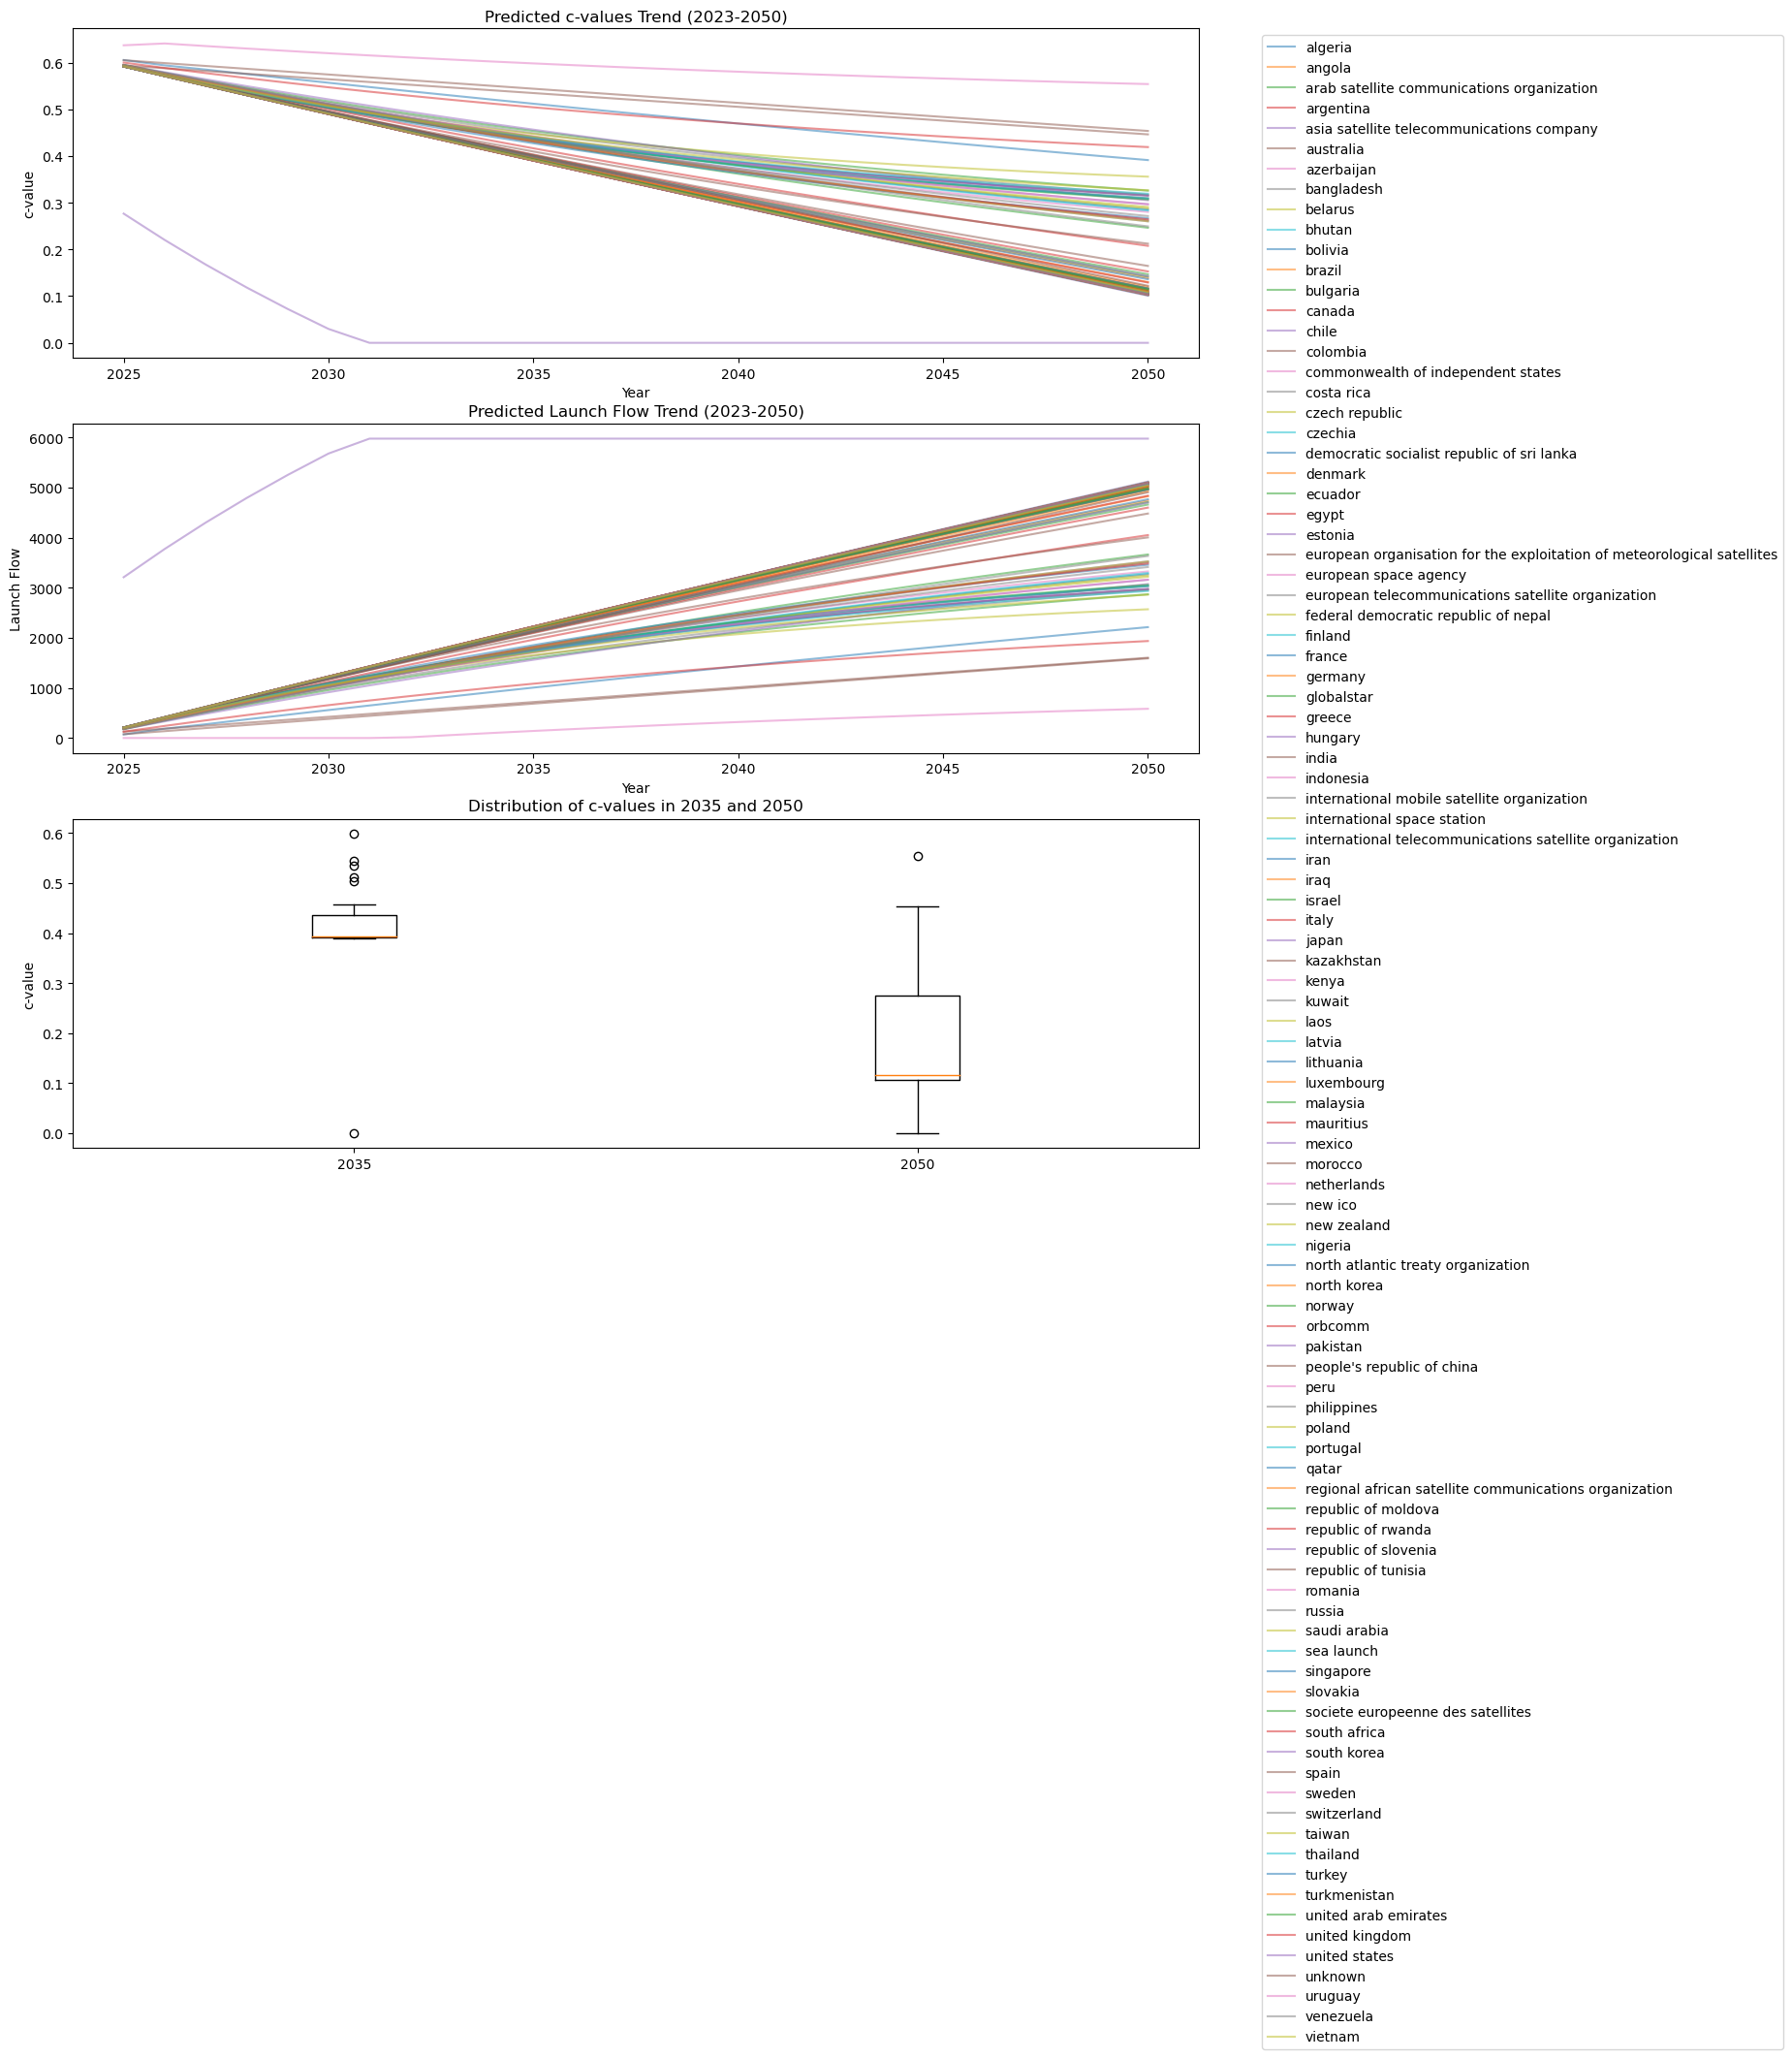


模拟结果数据预览（前5行）：
     country countrycode  year                                 Launch_site  \
1    algeria         ALG  1957  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   
102  algeria         ALG  1958  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   
202  algeria         ALG  1959  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   
302  algeria         ALG  1960  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   
402  algeria         ALG  1961  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   

     flow_launch  stock_launch  X_total_cum       LHS     c_hat  gamma_hat  \
1              0             0            3  0.999981  0.878201  -0.039632   
102            0             0           14  0.999913  0.878201  -0.039632   
202            0             0           37  0.999771  0.878201  -0.039632   
302            0             0           89  0.999448  0.878201  -0.039632   
402            0             0          508  0.996850  0.878201  -0.039632   

     c_hat_constrained  gamma_hat_constrained 

In [ ]:
# 5. 可视化函数
def plot_results(df, predictions):
    # 创建画布
    plt.figure(figsize=(15, 15))
    
    # c值预测趋势
    plt.subplot(3, 1, 1)
    for country in predictions['country'].unique():
        country_pred = predictions[predictions['country'] == country]
        plt.plot(country_pred['year'], country_pred['c_pred'], alpha=0.5, label=country)
    plt.title('Predicted c-values Trend (2023-2050)')
    plt.xlabel('Year')
    plt.ylabel('c-value')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 发射量预测趋势
    plt.subplot(3, 1, 2)
    for country in predictions['country'].unique():
        country_pred = predictions[predictions['country'] == country]
        plt.plot(country_pred['year'], country_pred['flow_launch_pred'], alpha=0.5, label=country)
    plt.title('Predicted Launch Flow Trend (2023-2050)')
    plt.xlabel('Year')
    plt.ylabel('Launch Flow')
    
    # c值在2035和2050年的分布
    plt.subplot(3, 1, 3)
    years_to_plot = [2035, 2050]
    c_data = [predictions[predictions['year'] == year]['c_pred'] for year in years_to_plot]
    plt.boxplot(c_data, labels=['2035', '2050'])
    plt.title('Distribution of c-values in 2035 and 2050')
    plt.ylabel('c-value')
    
    plt.tight_layout()
    plt.show()

# 主函数
def main():
    try:
        print("Using existing processed data")
        
        # 3. 模拟分析
        df_sim, launched_data, non_launched_data = simulation_analysis(df)
        print("Simulation analysis completed")
        
        # 4. 预测分析
        predictions = forecast_analysis(launched_data)
        print("Forecast analysis completed")
        
        # 5. 输出结果
        print("\nPrediction Summary:")
        print("\nYear 2035:")
        pred_2035 = predictions[predictions['year'] == 2035]
        print("\nc-value statistics:")
        print(pred_2035['c_pred'].describe())
        print("\nLaunch flow statistics:")
        print(pred_2035['flow_launch_pred'].describe())
        
        print("\nYear 2050:")
        pred_2050 = predictions[predictions['year'] == 2050]
        print("\nc-value statistics:")
        print(pred_2050['c_pred'].describe())
        print("\nLaunch flow statistics:")
        print(pred_2050['flow_launch_pred'].describe())
        
        # 6. 可视化结果
        plot_results(df_sim, predictions)
        
        # 7. 保存结果到CSV文件
        df_sim.to_csv('simulation_results.csv', index=False)
        predictions.to_csv('predictions_results.csv', index=False)
        
        # 8. 输出详细数据
        print("\n模拟结果数据预览（前5行）：")
        print(df_sim.head())
        print("\n预测结果数据预览（前5行）：")
        print(predictions.head())
        
        # 9. 输出基本统计信息
        print("\n模拟结果基本统计：")
        print(df_sim.describe())
        print("\n预测结果基本统计：")
        print(predictions.describe())
        
        return df_sim, predictions
        
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None, None

# 运行分析a
df_result, predictions = main()

In [ ]:
# 在main()运行之后添加以下代码

def calculate_equilibrium_parameters(countries, tau=0.0000062, gamma=0.0001):
    """
    计算均衡所需的固定参数
    """
    # 计算每个国家的αi（由于gamma固定，所有国家的αi相同）
    alpha = 1 / (tau + gamma)
    alphas = {country: alpha for country in countries}
    
    # 计算分母项 1/τ + Σαj
    n = len(countries)
    denominator = (1/tau) + (n * alpha)
    
    # 计算每个国家的λi（由于alpha相同，所有国家的λi也相同）
    lambda_i = alpha / denominator
    lambdas = {country: lambda_i for country in countries}
    
    print(f"\n参数计算过程:")
    print(f"tau = {tau}, gamma = {gamma}")
    print(f"alpha = 1/({tau} + {gamma}) = {alpha}")
    print(f"国家数量 n = {n}")
    print(f"分母 = 1/{tau} + {n} * {alpha} = {denominator}")
    print(f"lambda = {alpha} / {denominator} = {lambda_i}")
    
    return alphas, lambdas

def calculate_launches(predictions, alphas, lambdas):
    """
    根据预测的c值计算每个国家的发射量
    xi = αi[(1-ci) - Σλj(1-cj)]
    """
    new_predictions = predictions.copy()
    new_predictions['theoretical_flow_launch'] = 0.0
    new_predictions['sum_lambda_c'] = 0.0  # 添加新列
    
    for year in new_predictions['year'].unique():
        year_data = new_predictions[new_predictions['year'] == year]
        
        # 计算当年的Σλj(1-cj)
        sum_lambda_c = 0
        for _, row in year_data.iterrows():
            country = row['country']
            c_j = row['c_pred']
            term = lambdas[country] * (1 - c_j)
            sum_lambda_c += term
        
        # 将sum_lambda_c值添加到该年份的所有行
        new_predictions.loc[new_predictions['year'] == year, 'sum_lambda_c'] = sum_lambda_c
        
        # 计算每个国家的发射量
        for country in year_data['country'].unique():
            country_mask = (new_predictions['year'] == year) & (new_predictions['country'] == country)
            c_i = new_predictions.loc[country_mask, 'c_pred'].iloc[0]
            x_i = alphas[country] * ((1 - c_i) - sum_lambda_c)
            new_predictions.loc[country_mask, 'theoretical_flow_launch'] = max(x_i, 0)
    
    return new_predictions

# 主要计算过程
countries = predictions['country'].unique()
print(f"\n总计{len(countries)}个国家参与计算")

# 计算均衡参数
alphas, lambdas = calculate_equilibrium_parameters(countries)

# 保存alpha和lambda值
alpha_lambda_df = pd.DataFrame({
    'country': list(alphas.keys()),
    'alpha': list(alphas.values()),
    'lambda': list(lambdas.values())
})
alpha_lambda_df.to_csv('alpha_lambda_values.csv', index=False)
print("\nAlpha和Lambda值已保存到 'alpha_lambda_values.csv'")

# 计算发射量
new_predictions = calculate_launches(predictions, alphas, lambdas)

# 输出结果统计
print("\n基于理论公式的发射量预测统计:")
print("\n2035年:")
pred_2035 = new_predictions[new_predictions['year'] == 2035]
print(pred_2035[['country', 'c_pred', 'theoretical_flow_launch']].to_string())

print("\n2050年:")
pred_2050 = new_predictions[new_predictions['year'] == 2050]
print(pred_2050[['country', 'c_pred', 'theoretical_flow_launch']].to_string())

# 保存新的预测结果
new_predictions.to_csv('theoretical_predictions_results.csv', index=False)
print("\n新的预测结果已保存到 'theoretical_predictions_results.csv'")


总计99个国家参与计算

参数计算过程:
tau = 6.2e-06, gamma = 0.0001
alpha = 1/(6.2e-06 + 0.0001) = 9416.195856873823
国家数量 n = 99
分母 = 1/6.2e-06 + 99 * 9416.195856873823 = 1093493.7124111536
lambda = 9416.195856873823 / 1093493.7124111536 = 0.008611111111111111

Alpha和Lambda值已保存到 'alpha_lambda_values.csv'

基于理论公式的发射量预测统计:

2035年:
                                                                    country        c_pred  theoretical_flow_launch
78                                                                  algeria  4.401382e-01               533.717720
78                                                                   angola  3.913258e-01               993.344919
78                               arab satellite communications organization  3.907758e-01               998.523806
78                                                                argentina  3.950622e-01               958.162384
78                                asia satellite telecommunications company  3.904205e-01              1001.86

In [17]:
# 导入基础数据
df = pd.read_csv('simulation_results.csv')

# 删除指定的列
columns_to_drop = ['c_hat', 'gamma_hat', 'gamma_hat_constrained', 
                   'c_hat_constrained', 'LHS_pred']
df = df.drop(columns=columns_to_drop)

# 计算每年的cost_global（基于flow_launch=0的样本）
cost_global_by_year = df[df['flow_launch'] == 0].groupby('year')['c_sim'].first()

# 为每个样本添加对应年份的cost_global
df['cost_global'] = df['year'].map(cost_global_by_year)

# 生成launch_status变量
df['launch_status'] = (df['flow_launch'] > 0).astype(int)

# 保存新的数据集
df.to_csv('simulation_latestlaunch.csv', index=False)

# 输出处理结果摘要
print("数据处理完成：")
print(f"总样本数: {len(df)}")
print("\n前5行数据预览：")
print(df.head())
print("\n每年的cost_global值：")
print(cost_global_by_year)
print("\nlaunch_status的分布：")
print(df['launch_status'].value_counts())

数据处理完成：
总样本数: 6743

前5行数据预览：
   country countrycode  year                                 Launch_site  \
0  algeria         ALG  1957  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   
1  algeria         ALG  1958  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   
2  algeria         ALG  1959  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   
3  algeria         ALG  1960  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   
4  algeria         ALG  1961  PLESETSK MISSILE AND SPACE COMPLEX (PKMTR)   

   flow_launch  stock_launch  X_total_cum       LHS  gamma_fixed     c_sim  \
0            0             0            3  0.999981       0.0001  0.999981   
1            0             0           14  0.999913       0.0001  0.999913   
2            0             0           37  0.999771       0.0001  0.999771   
3            0             0           89  0.999448       0.0001  0.999448   
4            0             0          508  0.996850       0.0001  0.996850   

   cost_global  launch_status  
0     0.99998

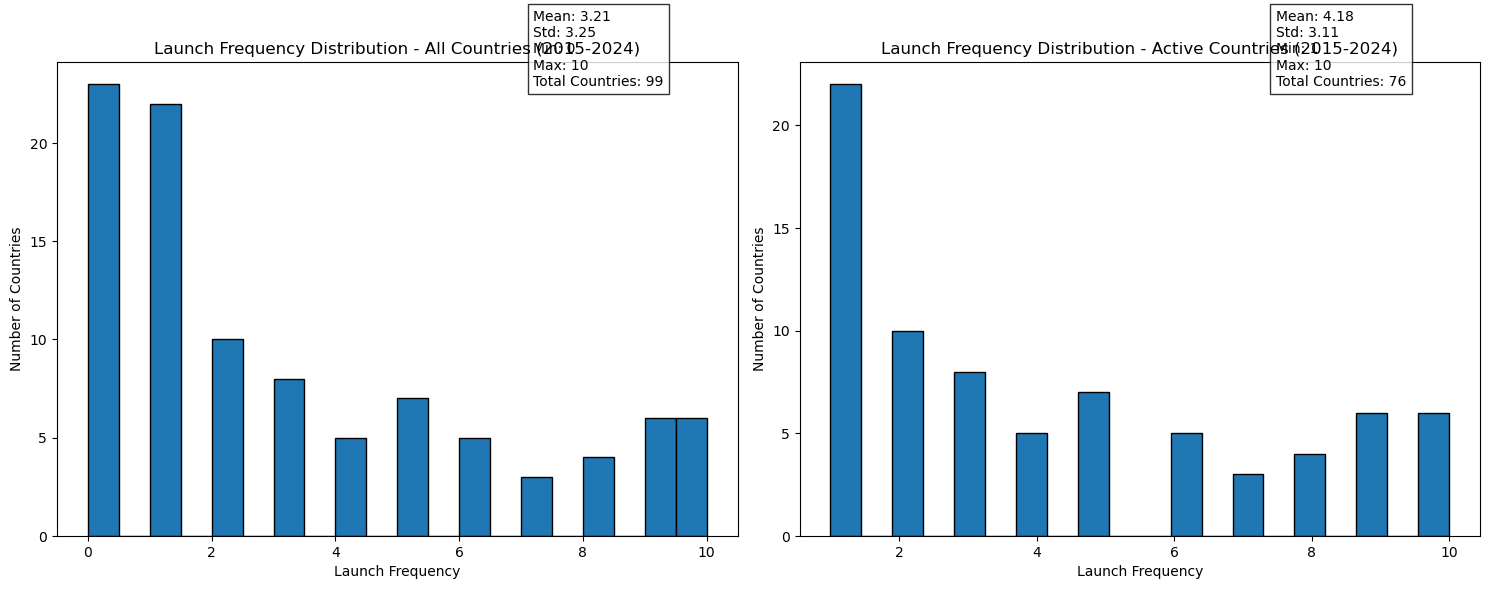


Launch Frequency Statistics - All Countries:
count    99.000000
mean      3.212121
std       3.252229
min       0.000000
25%       1.000000
50%       2.000000
75%       5.000000
max      10.000000
Name: frequency_launch, dtype: float64

Launch Frequency Statistics - Active Countries:
count    76.000000
mean      4.184211
std       3.114313
min       1.000000
25%       1.000000
50%       3.000000
75%       6.250000
max      10.000000
Name: frequency_launch, dtype: float64

Launch frequency data saved to 'launch_frequency_2015_2024.csv'

Top 10 Countries by Launch Frequency:
                               country  frequency_launch
16  commonwealth of independent states                10
30                              france                10
35                               india                10
44                               japan                10
65          people's republic of china                10
94                       united states                10
3                   

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate launch frequency between 2015-2024
launch_freq = df[
    (df['year'] >= 2015) & 
    (df['year'] <= 2024)
].groupby('country')['launch_status'].sum().reset_index()
launch_freq.columns = ['country', 'frequency_launch']

# Merge frequency info with 2024 data
df_2024 = df[df['year'] == 2024].copy()
df_2024 = df_2024.merge(launch_freq, on='country', how='left')

# Create figure
plt.figure(figsize=(15, 6))

# Subplot 1: Distribution for all countries
plt.subplot(1, 2, 1)
plt.hist(df_2024['frequency_launch'], bins=20, edgecolor='black')
plt.title('Launch Frequency Distribution - All Countries (2015-2024)')
plt.xlabel('Launch Frequency')
plt.ylabel('Number of Countries')

# Add descriptive statistics
stats_all = df_2024['frequency_launch'].describe()
plt.text(0.7, 0.95, 
         f'Mean: {stats_all["mean"]:.2f}\nStd: {stats_all["std"]:.2f}\n' + 
         f'Min: {stats_all["min"]:.0f}\nMax: {stats_all["max"]:.0f}\n' +
         f'Total Countries: {len(df_2024)}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

# Subplot 2: Distribution for active countries only
df_2024_active = df_2024[df_2024['frequency_launch'] > 0]
plt.subplot(1, 2, 2)
plt.hist(df_2024_active['frequency_launch'], bins=20, edgecolor='black')
plt.title('Launch Frequency Distribution - Active Countries (2015-2024)')
plt.xlabel('Launch Frequency')
plt.ylabel('Number of Countries')

# Add descriptive statistics
stats_active = df_2024_active['frequency_launch'].describe()
plt.text(0.7, 0.95, 
         f'Mean: {stats_active["mean"]:.2f}\nStd: {stats_active["std"]:.2f}\n' + 
         f'Min: {stats_active["min"]:.0f}\nMax: {stats_active["max"]:.0f}\n' +
         f'Total Countries: {len(df_2024_active)}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nLaunch Frequency Statistics - All Countries:")
print(stats_all)
print("\nLaunch Frequency Statistics - Active Countries:")
print(stats_active)

# Save frequency data
launch_freq.to_csv('launch_frequency_2015_2024.csv', index=False)
print("\nLaunch frequency data saved to 'launch_frequency_2015_2024.csv'")

# Print top 10 most active countries
print("\nTop 10 Countries by Launch Frequency:")
print(launch_freq.nlargest(10, 'frequency_launch'))

Major Players (Launch Frequency >= 5):
Total number of major players: 31

Detailed list of major players:
                                              country  frequency_launch
94                                      united states                10
35                                              india                10
16                 commonwealth of independent states                10
65                         people's republic of china                10
44                                              japan                10
30                                             france                10
93                                     united kingdom                 9
85                                              spain                 9
5                                           australia                 9
3                                           argentina                 9
26                              european space agency                 9
31                            

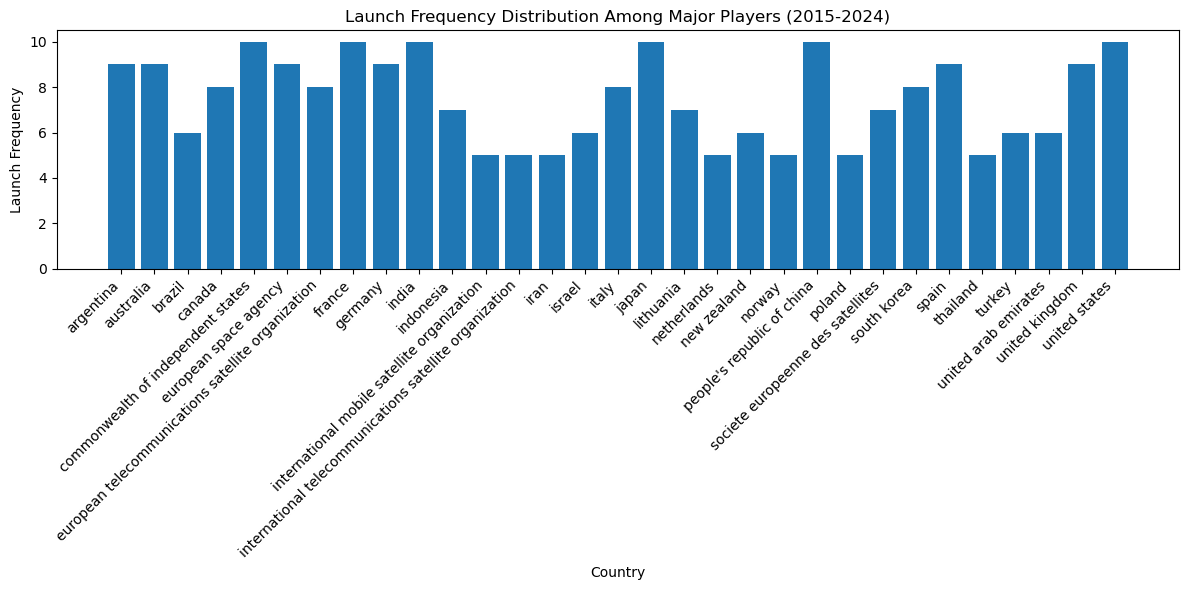

In [19]:
# 筛选发射频率大于等于5的国家
major_players = launch_freq[launch_freq['frequency_launch'] >= 5]

# 打印主要参与者信息
print("Major Players (Launch Frequency >= 5):")
print(f"Total number of major players: {len(major_players)}")
print("\nDetailed list of major players:")
print(major_players.sort_values('frequency_launch', ascending=False))

# 使用这些主要参与者筛选原始数据
major_players_list = major_players['country'].tolist()
df_major = df[df['country'].isin(major_players_list)].copy()

# 打印数据集信息
print(f"\nOriginal dataset size: {len(df)}")
print(f"Major players dataset size: {len(df_major)}")
print(f"Percentage of data retained: {(len(df_major)/len(df)*100):.2f}%")

# 保存主要参与者名单
major_players.to_csv('major_players_list.csv', index=False)
print("\nMajor players list saved to 'major_players_list.csv'")

# 保存主要参与者的完整数据
df_major.to_csv('major_players_data.csv', index=False)
print("Major players complete data saved to 'major_players_data.csv'")

# 显示每个主要参与者的发射频率分布
plt.figure(figsize=(12, 6))
plt.bar(range(len(major_players)), major_players['frequency_launch'])
plt.xticks(range(len(major_players)), major_players['country'], rotation=45, ha='right')
plt.title('Launch Frequency Distribution Among Major Players (2015-2024)')
plt.xlabel('Country')
plt.ylabel('Launch Frequency')
plt.tight_layout()
plt.show()

使用主要参与者数据进行分析
主要参与者模拟分析完成


c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\base\model.py:567: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn("Maximum Likelihood optimization failed to converge. "
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\base\model.py:567: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn("Maximum Likelihood optimization failed to converge. "
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:963: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\base\model.py:567: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn("Maximum Likelihood optimization failed to converge. "
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\base\model.


主要参与者的ARIMA模型阶数:
argentina: ARIMA(1, 1, 2)
australia: ARIMA(1, 1, 1)
brazil: ARIMA(1, 1, 1)
canada: ARIMA(1, 1, 1)
commonwealth of independent states: ARIMA(1, 1, 2)
european space agency: ARIMA(1, 1, 1)
european telecommunications satellite organization: ARIMA(1, 1, 1)
france: ARIMA(2, 1, 1)
germany: ARIMA(1, 1, 1)
india: ARIMA(2, 1, 2)
indonesia: ARIMA(1, 1, 2)
international mobile satellite organization: ARIMA(2, 1, 0)
international telecommunications satellite organization: ARIMA(2, 1, 0)
iran: ARIMA(1, 1, 1)
israel: ARIMA(1, 1, 1)
italy: ARIMA(1, 1, 1)
japan: ARIMA(1, 1, 1)
lithuania: ARIMA(1, 1, 1)
netherlands: ARIMA(1, 1, 1)
new zealand: ARIMA(1, 1, 1)
norway: ARIMA(2, 1, 0)
people's republic of china: ARIMA(1, 1, 2)
poland: ARIMA(1, 1, 1)
societe europeenne des satellites: ARIMA(1, 1, 1)
south korea: ARIMA(1, 1, 1)
spain: ARIMA(1, 1, 1)
thailand: ARIMA(1, 1, 1)
turkey: ARIMA(1, 1, 1)
united arab emirates: ARIMA(1, 1, 1)
united kingdom: ARIMA(1, 1, 1)
united states: ARIMA(1, 1,

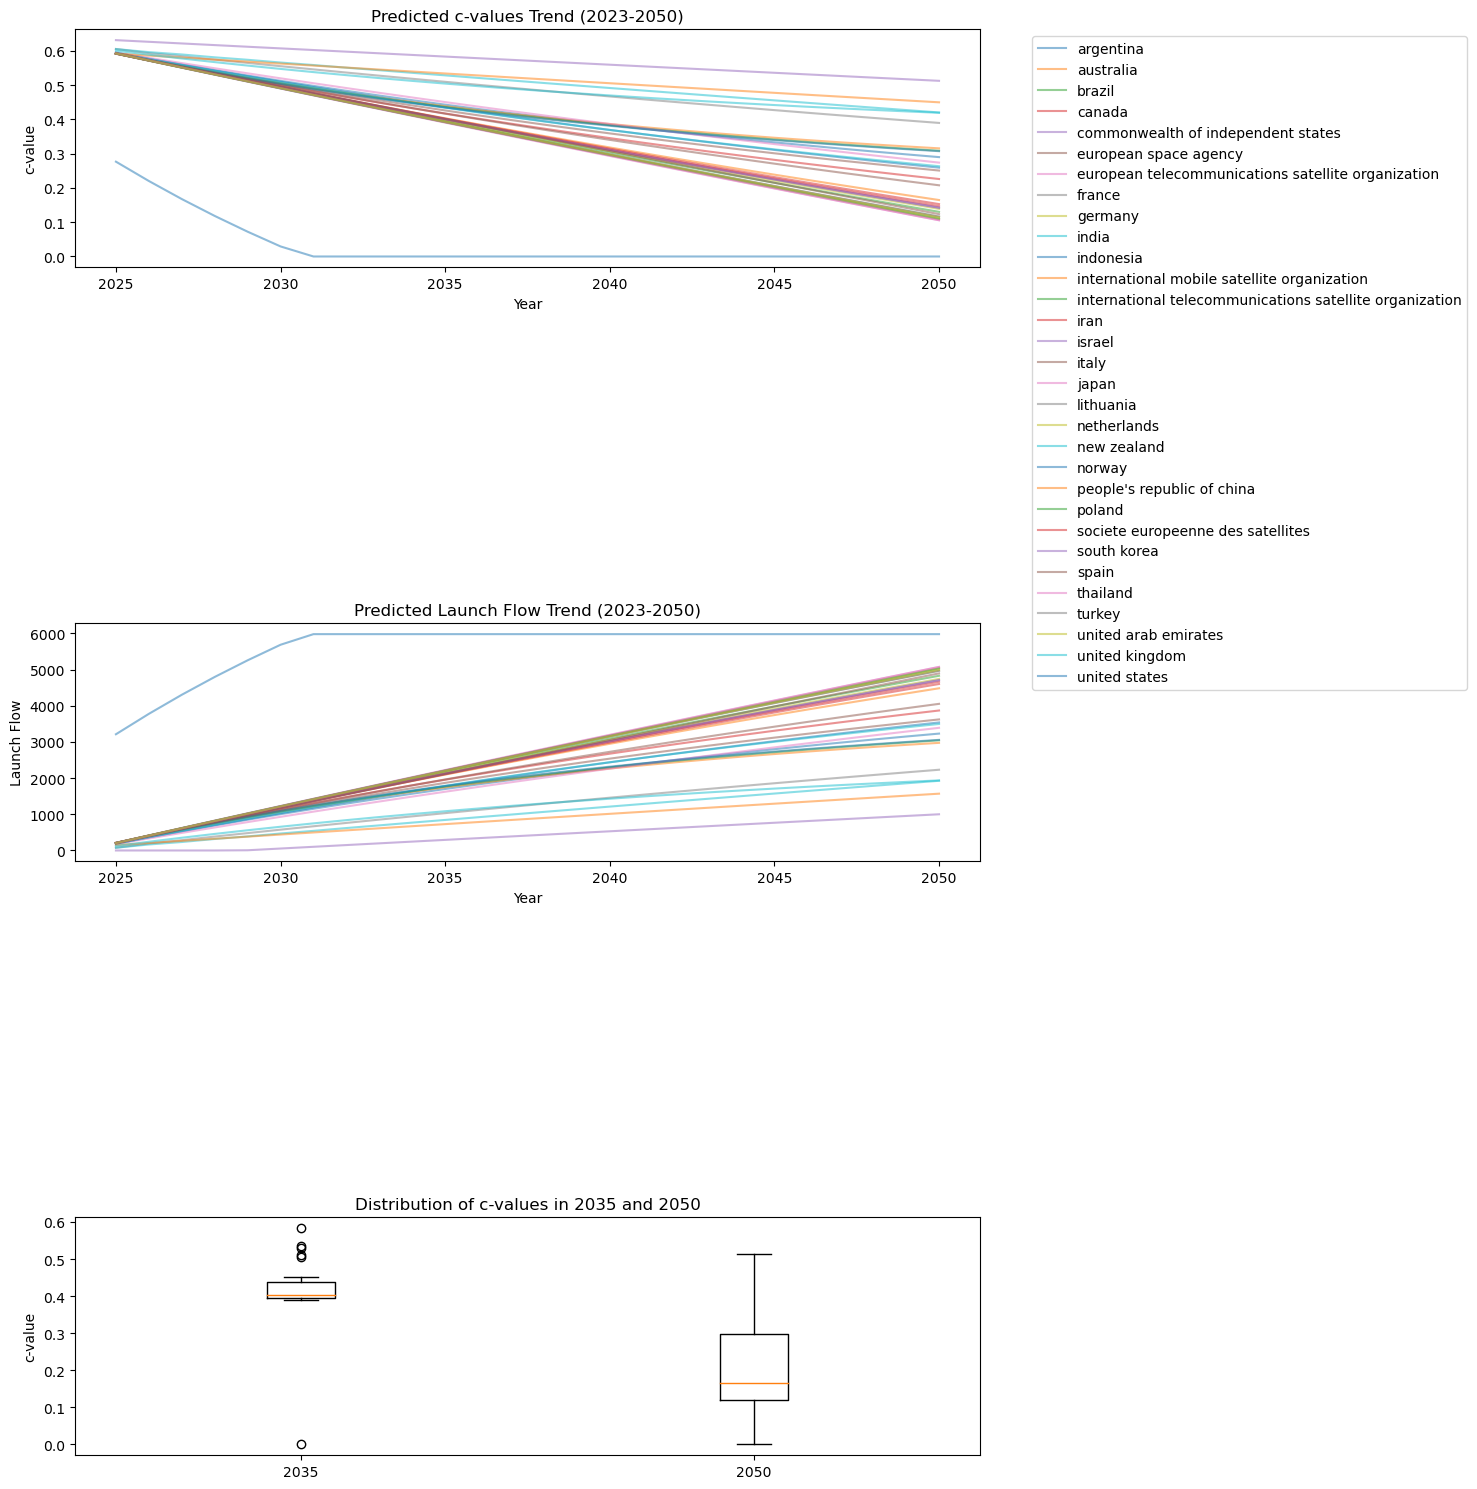


结果已保存到 'major_players_simulation_results.csv' 和 'major_players_predictions_results.csv'


In [20]:
# 读取major players数据
df_major = pd.read_csv('major_players_data.csv')

def simulation_analysis_major(df):
    """
    针对主要参与者的模拟分析函数
    """
    # 创建新的预测结果列
    df['gamma_fixed'] = 0.0001  # 固定gamma值
    df['c_sim'] = df['LHS'] - (0.0001 * df['flow_launch'])
    df['LHS_pred'] = df['c_sim'] + (0.0001 * df['flow_launch'])
    
    return df

def forecast_analysis_major(df):
    """
    针对主要参与者的预测分析函数
    """
    current_year = df['year'].max()
    years_to_2050 = 2050 - current_year
    predictions = pd.DataFrame()
    arima_orders = {}  # 用于存储每个国家的ARIMA阶数
    
    for country in df['country'].unique():
        country_data = df[df['country'] == country]
        
        try:
            c_series = country_data['c_sim']
            
            if len(c_series) > 5:
                order = find_best_arima_order(c_series)
            else:
                order = (1,0,0)
            
            arima_orders[country] = order
            
            model = ARIMA(c_series, order=order)
            results = model.fit()
            c_forecast = results.forecast(steps=years_to_2050)
            c_forecast = np.maximum(c_forecast, 1e-10)
            
            country_predictions = pd.DataFrame({
                'year': range(current_year + 1, 2051),
                'country': country,
                'c_pred': c_forecast,
                'arima_order': str(order)
            })
            
            last_lhs = country_data['LHS'].iloc[-1]
            country_predictions['flow_launch_pred'] = np.maximum(
                (last_lhs - country_predictions['c_pred']) / 0.0001, 
                0
            )
            
            predictions = pd.concat([predictions, country_predictions])
            
        except Exception as e:
            print(f"预测{country}时出错: {str(e)}")
            continue
    
    print("\n主要参与者的ARIMA模型阶数:")
    for country, order in arima_orders.items():
        print(f"{country}: ARIMA{order}")
    
    return predictions

def main_major_players():
    try:
        print("使用主要参与者数据进行分析")
        
        # 模拟分析
        df_sim = simulation_analysis_major(df_major)
        print("主要参与者模拟分析完成")
        
        # 预测分析
        predictions = forecast_analysis_major(df_sim)
        print("主要参与者预测分析完成")
        
        # 输出结果
        print("\n预测结果摘要:")
        print("\n2035年:")
        pred_2035 = predictions[predictions['year'] == 2035]
        print("\nc值统计:")
        print(pred_2035['c_pred'].describe())
        print("\n发射量统计:")
        print(pred_2035['flow_launch_pred'].describe())
        
        print("\n2050年:")
        pred_2050 = predictions[predictions['year'] == 2050]
        print("\nc值统计:")
        print(pred_2050['c_pred'].describe())
        print("\n发射量统计:")
        print(pred_2050['flow_launch_pred'].describe())
        
        # 可视化结果
        plot_results(df_sim, predictions)
        
        # 保存结果
        df_sim.to_csv('major_players_simulation_results.csv', index=False)
        predictions.to_csv('major_players_predictions_results.csv', index=False)
        
        print("\n结果已保存到 'major_players_simulation_results.csv' 和 'major_players_predictions_results.csv'")
        
        return df_sim, predictions
        
    except Exception as e:
        print(f"发生错误: {str(e)}")
        return None, None

# 运行主要参与者分析
df_major_result, major_predictions = main_major_players()

In [21]:
# 使用major_players的预测结果进行均衡计算

# 读取预测数据
major_predictions = pd.read_csv('major_players_predictions_results.csv')

# 计算主要参与者的均衡参数
major_countries = major_predictions['country'].unique()
print(f"\n总计{len(major_countries)}个主要参与国家参与计算")

# 计算均衡参数 (使用相同的tau和gamma值)
major_alphas, major_lambdas = calculate_equilibrium_parameters(major_countries, tau=0.0000062, gamma=0.0001)

# 保存主要参与者的alpha和lambda值
major_alpha_lambda_df = pd.DataFrame({
    'country': list(major_alphas.keys()),
    'alpha': list(major_alphas.values()),
    'lambda': list(major_lambdas.values())
})
major_alpha_lambda_df.to_csv('major_players_alpha_lambda_values.csv', index=False)
print("\n主要参与者的Alpha和Lambda值已保存到 'major_players_alpha_lambda_values.csv'")

# 计算主要参与者的理论发射量
major_theoretical_predictions = calculate_launches(major_predictions, major_alphas, major_lambdas)

# 输出主要参与者的结果统计
print("\n主要参与者基于理论公式的发射量预测统计:")
print("\n2035年:")
major_pred_2035 = major_theoretical_predictions[major_theoretical_predictions['year'] == 2035]
print(major_pred_2035[['country', 'c_pred', 'theoretical_flow_launch']].to_string())

print("\n2050年:")
major_pred_2050 = major_theoretical_predictions[major_theoretical_predictions['year'] == 2050]
print(major_pred_2050[['country', 'c_pred', 'theoretical_flow_launch']].to_string())

# 保存主要参与者的新预测结果
major_theoretical_predictions.to_csv('major_players_theoretical_predictions_results.csv', index=False)
print("\n主要参与者的新预测结果已保存到 'major_players_theoretical_predictions_results.csv'")

# 添加结果比较
print("\n预测结果比较分析:")
for year in [2035, 2050]:
    year_data = major_theoretical_predictions[major_theoretical_predictions['year'] == year]
    print(f"\n{year}年预测统计:")
    print("\n原始预测发射量统计:")
    print(year_data['flow_launch_pred'].describe())
    print("\n理论模型发射量统计:")
    print(year_data['theoretical_flow_launch'].describe())


总计31个主要参与国家参与计算

参数计算过程:
tau = 6.2e-06, gamma = 0.0001
alpha = 1/(6.2e-06 + 0.0001) = 9416.195856873823
国家数量 n = 31
分母 = 1/6.2e-06 + 31 * 9416.195856873823 = 453192.39414373366
lambda = 9416.195856873823 / 453192.39414373366 = 0.020777479892761394

主要参与者的Alpha和Lambda值已保存到 'major_players_alpha_lambda_values.csv'

主要参与者基于理论公式的发射量预测统计:

2035年:
                                                     country        c_pred  theoretical_flow_launch
10                                                 argentina  4.430743e-01              1711.302563
36                                                 australia  4.032993e-01              2085.831447
62                                                    brazil  3.958433e-01              2156.038338
88                                                    canada  4.025208e-01              2093.161680
114                       commonwealth of independent states  5.833931e-01               390.033327
140                                    european space ag